--- 1. FIRST 5 ROWS (df.head) ---


,Department,Age,Salary
0,Sales,31.00,300000.00
1,IT,40.00,49457.05
2,Sales,53.00,NaN
3,Sales,22.00,56962.06
4,IT,26.00,68489.56



--- 2. INITIAL MISSING VALUES ---
Department     0
Age           19
Salary        29
dtype: int64

--- 3. MISSING VALUES AFTER CLEANING ---
Department    0
Age           0
Salary        0
dtype: int64

--- 4. SUMMARY STATISTICS ---


,Age,Salary
count,500.00,500.00
mean,37.77,51217.96
std,9.47,9196.31
min,22.00,27079.15
25%,30.00,44944.48
50%,38.00,51379.98
75%,46.00,56854.70
max,54.00,74720.03


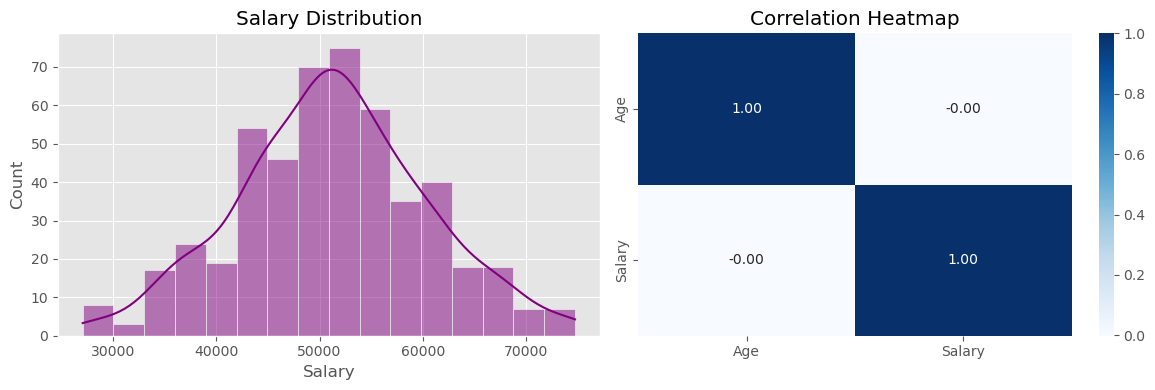

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 500
df = pd.DataFrame({
    'Department': np.random.choice(['IT', 'HR', 'Sales'], size=n),
    'Age': np.random.randint(22, 55, size=n),
    'Salary': np.random.normal(50000, 10000, size=n)
})

df.loc[np.random.choice(n, 30), 'Salary'] = np.nan
df.loc[np.random.choice(n, 20), 'Age'] = np.nan
df.loc[0, 'Salary'] = 300000  # Outlier

print("--- 1. FIRST 5 ROWS (df.head) ---")
display(df.head())

print("\n--- 2. INITIAL MISSING VALUES ---")
print(df.isnull().sum())

#3. Data Cleaning (Step-by-Step)

df['Salary'] = df['Salary'].fillna(df.groupby('Department')['Salary'].transform('median'))
df['Age'] = df['Age'].fillna(df['Age'].median())

# Handle Outliers using IQR
for col in ['Salary', 'Age']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("\n--- 3. MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())

print("\n--- 4. SUMMARY STATISTICS ---")
display(df.describe())

# 5. Visualizations
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Salary'], kde=True, color='purple')
plt.title('Salary Distribution')

plt.subplot(1, 2, 2)
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()